In [ ]:
# 1: Import all

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# 2: Load Dataset

df = pd.read_csv("/content/Mental-Health-Twitter.csv")
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [ ]:
# ===== Cell 3: Basic Info =====

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']
Shape: (20000, 11)


In [ ]:
# ===== Cell 4: Null and Duplicate Check =====

print("Missing values:\n")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values:

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

Total duplicate rows: 0


In [ ]:
# ===== Cell 5: Label Distribution =====

print(df["label"].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


In [ ]:
# ===== Cell 6: Keep Required Columns Only =====

df = df[["post_text", "label"]].copy()
df.head()

,post_text,label
0,It's just over 2 years since I was diagnosed w...,1
1,"It's Sunday, I need a break, so I'm planning t...",1
2,Awake but tired. I need to sleep but my brain ...,1
3,RT @SewHQ: #Retro bears make perfect gifts and...,1
4,It’s hard to say whether packing lists are mak...,1


In [ ]:
# ===== Cell 7: Standard Figure Style =====

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

sns.set_style("whitegrid")

In [ ]:
# ===== Cell 8: Download Stopwords =====

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Important: keep negation words
keep_words = {"not", "no", "nor", "never"}

stop_words = {word for word in stop_words if word not in keep_words}

print("Stopwords loaded successfully")

Stopwords loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# ===== Cell 9: Better Cleaning Function for This Dataset =====

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\brt\b", " ", text)
    text = text.replace("#", "")

    # keep apostrophe-style contractions effect removed to letters only
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
# ===== Cell 10: Create Cleaned Text =====

df["cleaned_text"] = df["post_text"].apply(clean_text)

# remove empty rows only
df = df[df["cleaned_text"] != ""].copy().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df[["post_text", "cleaned_text", "label"]].head()

Shape after cleaning: (20000, 3)


,post_text,cleaned_text,label
0,It's just over 2 years since I was diagnosed w...,it s just over years since i was diagnosed wit...,1
1,"It's Sunday, I need a break, so I'm planning t...",it s sunday i need a break so i m planning to ...,1
2,Awake but tired. I need to sleep but my brain ...,awake but tired i need to sleep but my brain h...,1
3,RT @SewHQ: #Retro bears make perfect gifts and...,retro bears make perfect gifts and are great f...,1
4,It’s hard to say whether packing lists are mak...,it s hard to say whether packing lists are mak...,1


In [ ]:
# ===== Cell 11: Text Length Feature =====

df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))
df[["cleaned_text", "text_length"]].head()

,cleaned_text,text_length
0,it s just over years since i was diagnosed wit...,28
1,it s sunday i need a break so i m planning to ...,21
2,awake but tired i need to sleep but my brain h...,13
3,retro bears make perfect gifts and are great f...,21
4,it s hard to say whether packing lists are mak...,22


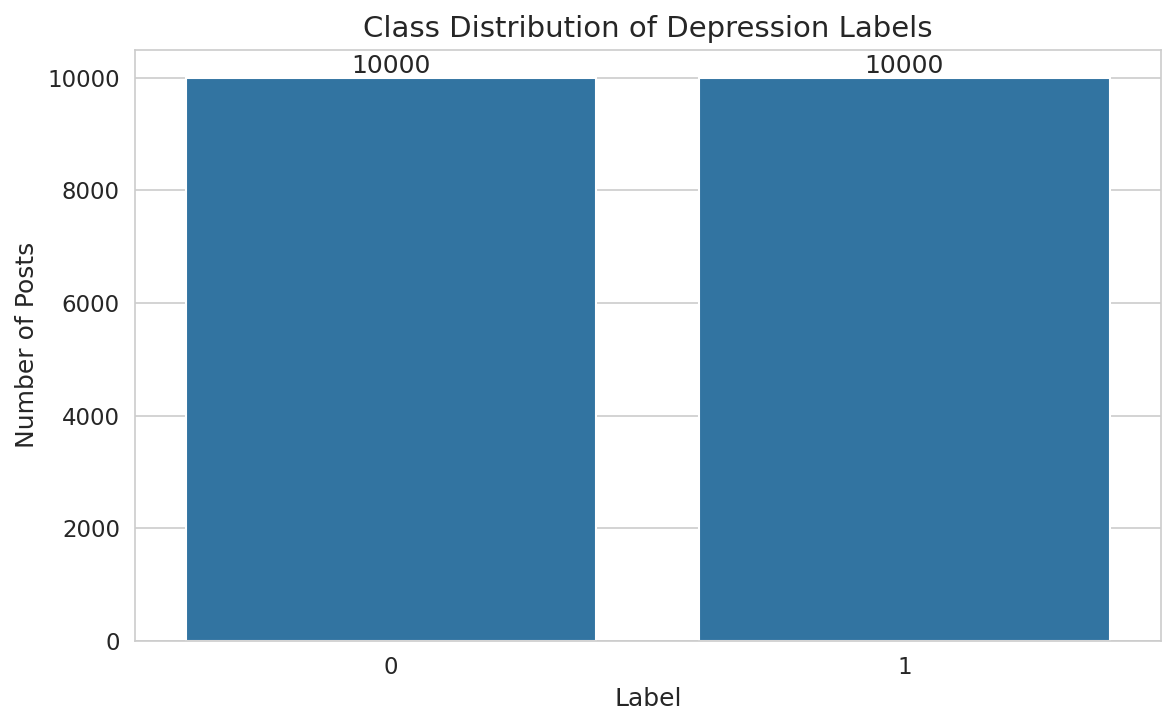

In [ ]:
# ===== Cell 12: Class Distribution Figure =====

plt.figure()
ax = sns.countplot(x="label", data=df)

plt.title("Class Distribution of Depression Labels")
plt.xlabel("Label")
plt.ylabel("Number of Posts")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()

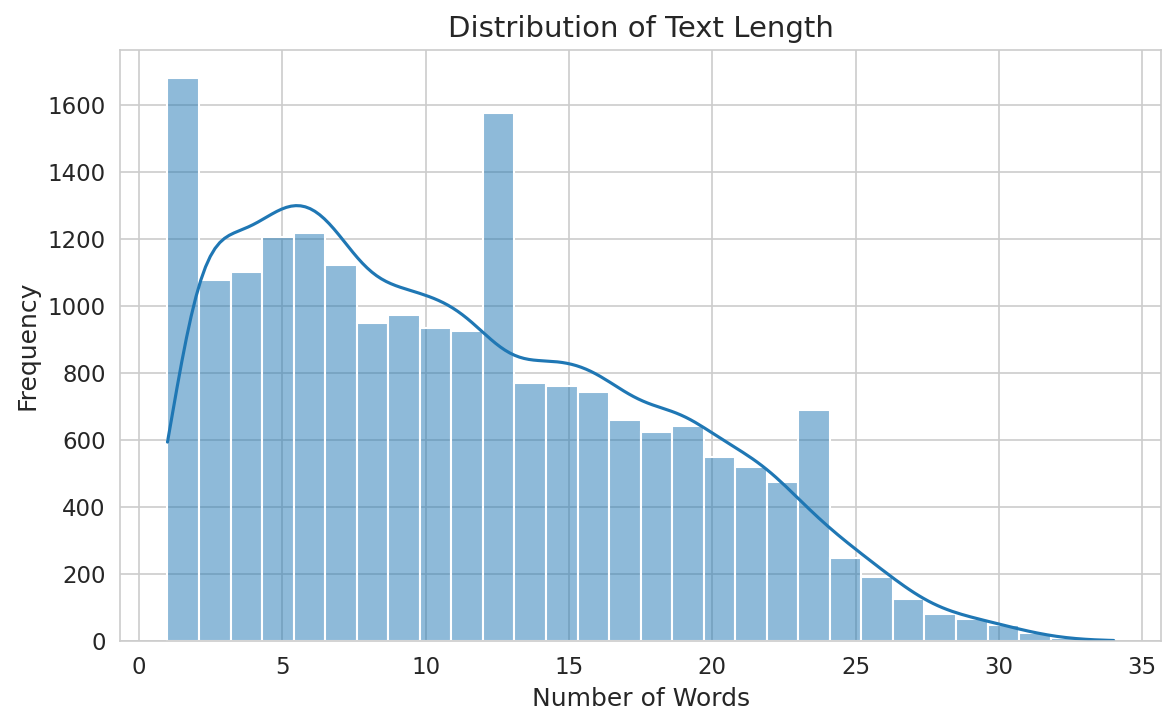

In [ ]:
# ===== Cell 13: Text Length Distribution Figure =====

plt.figure()
sns.histplot(data=df, x="text_length", bins=30, kde=True)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("text_length_distribution.png", bbox_inches="tight")
plt.show()

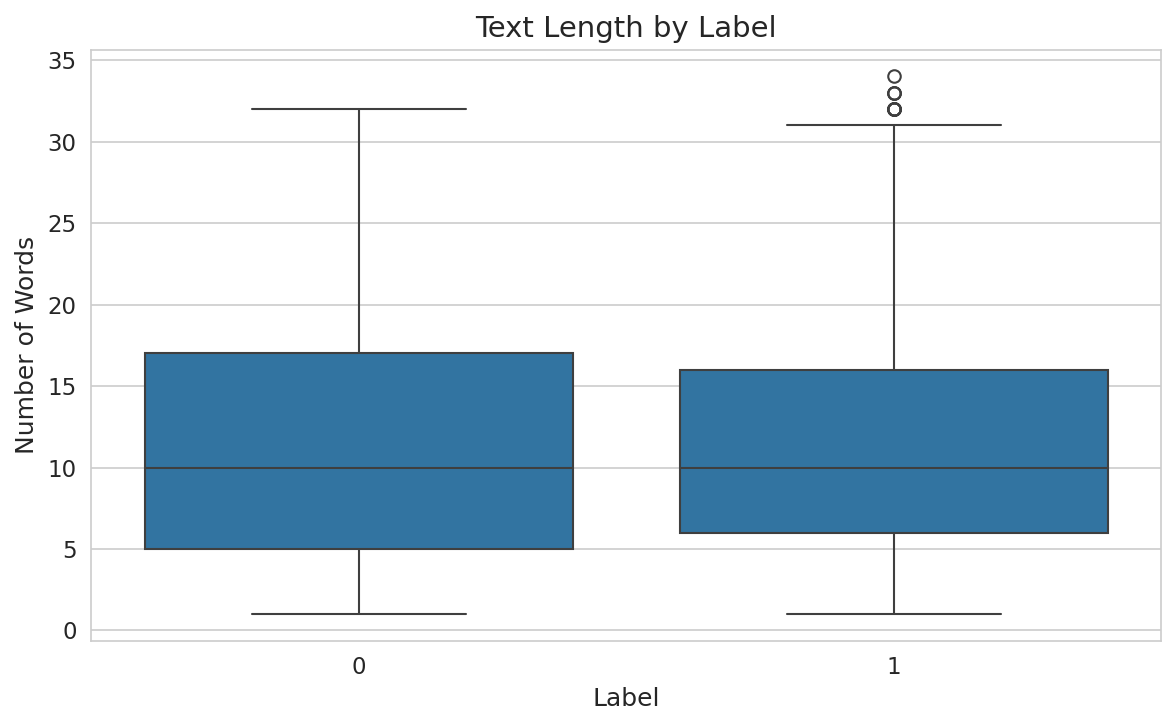

In [ ]:
# ===== Cell 14: Text Length by Label Figure =====

plt.figure()
sns.boxplot(x="label", y="text_length", data=df)

plt.title("Text Length by Label")
plt.xlabel("Label")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.savefig("text_length_by_label.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 15: Create X and y =====

X = df["cleaned_text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000,)
y shape: (20000,)


In [ ]:
# ===== Cell 16: Train-Test Split =====

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (16000,)
X_test shape : (4000,)
y_train shape: (16000,)
y_test shape : (4000,)


In [ ]:
# ===== Cell 17: Tuned TF-IDF =====

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape :", X_test_tfidf.shape)

X_train_tfidf shape: (16000, 10000)
X_test_tfidf shape : (4000, 10000)


In [ ]:
# ===== Cell 18: Better Logistic Regression =====

lr_model = LogisticRegression(
    C=1.0,
    max_iter=4000,
    solver="lbfgs"
)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.76075
Precision: 0.7456429580781913
Recall   : 0.7915
F1 Score : 0.7678874605869512


              precision    recall  f1-score   support

           0       0.78      0.73      0.75      2000
           1       0.75      0.79      0.77      2000

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000



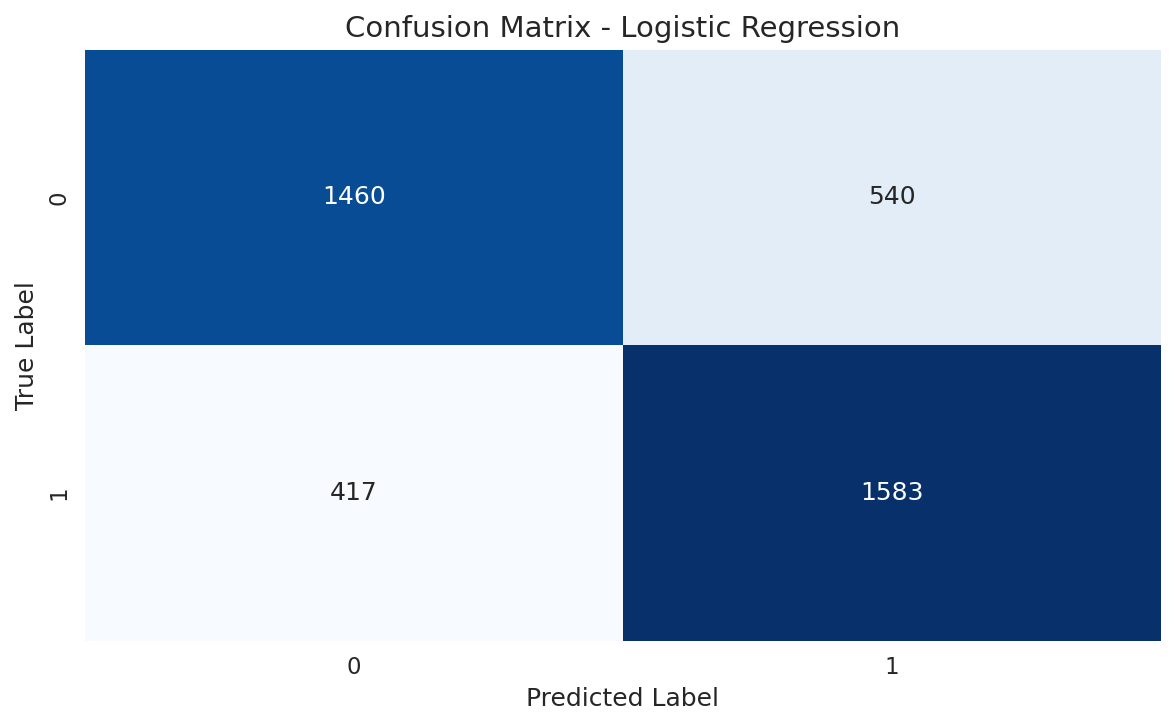

In [ ]:
# ===== Cell 19: Logistic Regression Report + Confusion Matrix =====

print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_logistic_regression.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 20: SVM Model =====

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000
)

svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Results")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM Results
Accuracy : 0.76
Precision: 0.7554027504911591
Recall   : 0.769
F1 Score : 0.7621407333994054


              precision    recall  f1-score   support

           0       0.76      0.75      0.76      2000
           1       0.76      0.77      0.76      2000

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000



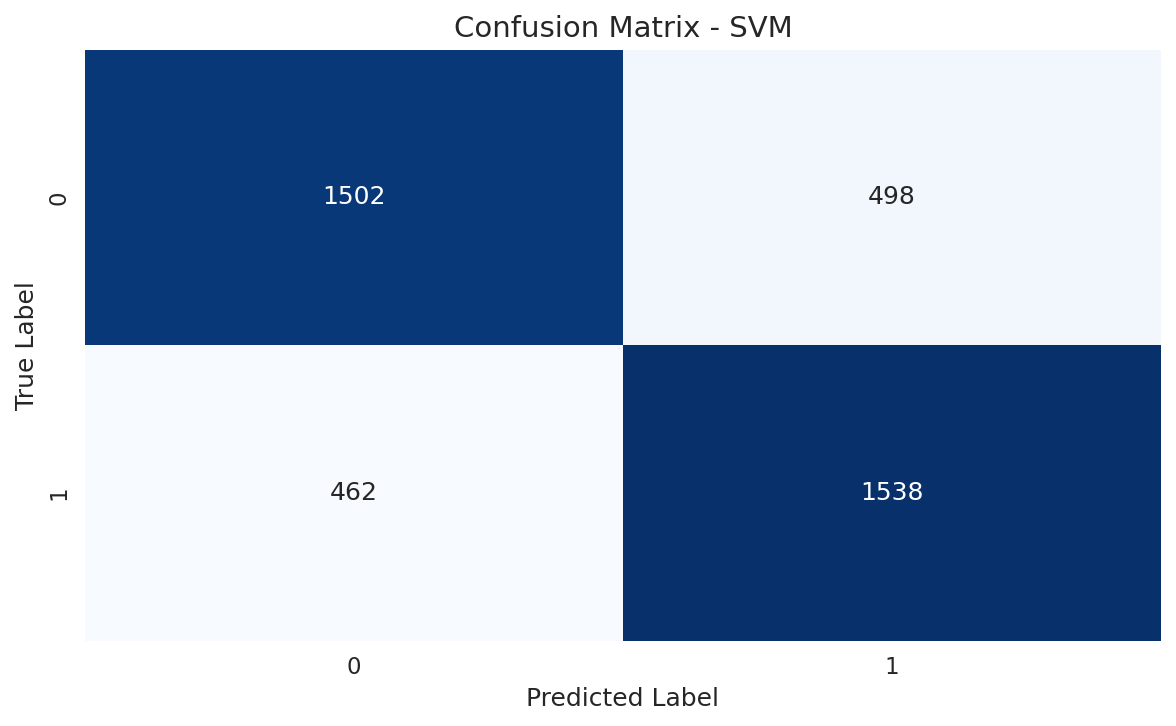

In [ ]:
# ===== Cell 21: SVM Report + Confusion Matrix =====

print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 22: Random Forest Model =====

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.737
Precision: 0.7077125328659071
Recall   : 0.8075
F1 Score : 0.7543204110228865


              precision    recall  f1-score   support

           0       0.78      0.67      0.72      2000
           1       0.71      0.81      0.75      2000

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



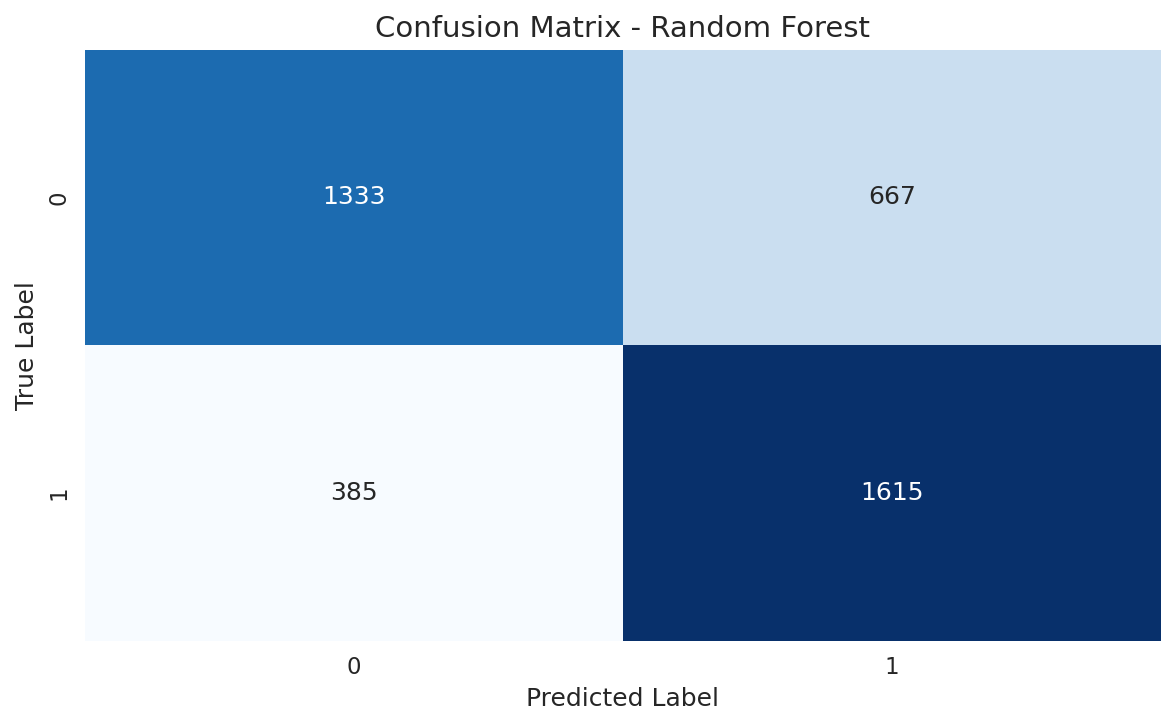

In [ ]:
# ===== Cell 23: Random Forest Report + Confusion Matrix =====

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_random_forest.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 24: ML Results Table =====

ml_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ]
})

ml_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76075,0.745643,0.7915,0.767887
1,SVM,0.76000,0.755403,0.7690,0.762141
2,Random Forest,0.73700,0.707713,0.8075,0.754320


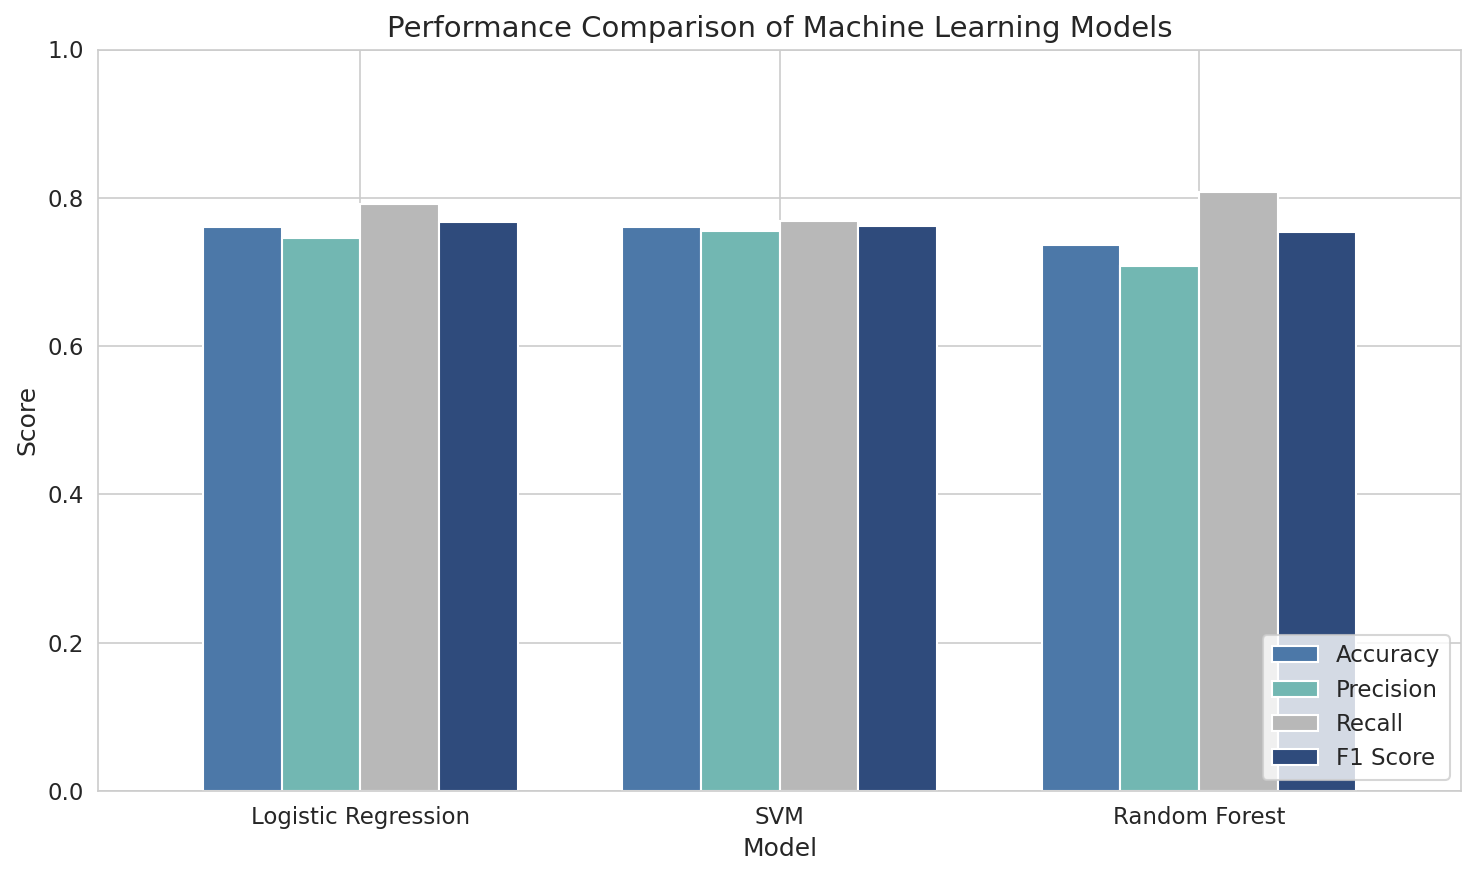

In [ ]:
# ===== Cell 25: ML Comparison Figure =====

ml_results_plot = ml_results.set_index("Model")

academic_colors = ["#4C78A8", "#72B7B2", "#B8B8B8", "#2F4B7C"]

ax = ml_results_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75,
    color=academic_colors
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("ml_models_comparison.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 26: Train-Validation Split for BiLSTM =====

X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train_dl shape:", X_train_dl.shape)
print("X_val_dl shape  :", X_val_dl.shape)
print("y_train_dl shape:", y_train_dl.shape)
print("y_val_dl shape  :", y_val_dl.shape)

X_train_dl shape: (12800,)
X_val_dl shape  : (3200,)
y_train_dl shape: (12800,)
y_val_dl shape  : (3200,)


In [ ]:
# ===== Cell 27: Tokenizer and Padding =====

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_dl)

X_train_seq = tokenizer.texts_to_sequences(X_train_dl)
X_val_seq = tokenizer.texts_to_sequences(X_val_dl)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("Vocabulary size:", len(tokenizer.word_index))
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape  :", X_val_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

Vocabulary size: 15297
X_train_pad shape: (12800, 50)
X_val_pad shape  : (3200, 50)
X_test_pad shape : (4000, 50)


In [ ]:
# ===== Cell 28: Build BiLSTM Model =====

bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_shape=(max_len,)),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(16, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,889 (2.54 MB)

 Trainable params: 665,889 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===== Cell 29: Train BiLSTM =====

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1
)

history = bilstm_model.fit(
    X_train_pad,
    y_train_dl,
    epochs=7,
    batch_size=256,
    validation_data=(X_val_pad, y_val_dl),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/7
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5488 - loss: 0.6868 - val_accuracy: 0.6344 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 2/7
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7019 - loss: 0.5711 - val_accuracy: 0.7466 - val_loss: 0.4983 - learning_rate: 0.0010
Epoch 3/7
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8318 - loss: 0.3832 - val_accuracy: 0.7650 - val_loss: 0.4622 - learning_rate: 0.0010
Epoch 4/7
45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8806 - loss: 0.2900
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8789 - loss: 0.2877 - val_accuracy: 0.7653 - val_loss: 0.5315 - learning_rate: 0.0010
Epoch 5/7
46/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9094 - loss: 0.2264
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9098 - loss: 0.2265 - val_accuracy: 0.

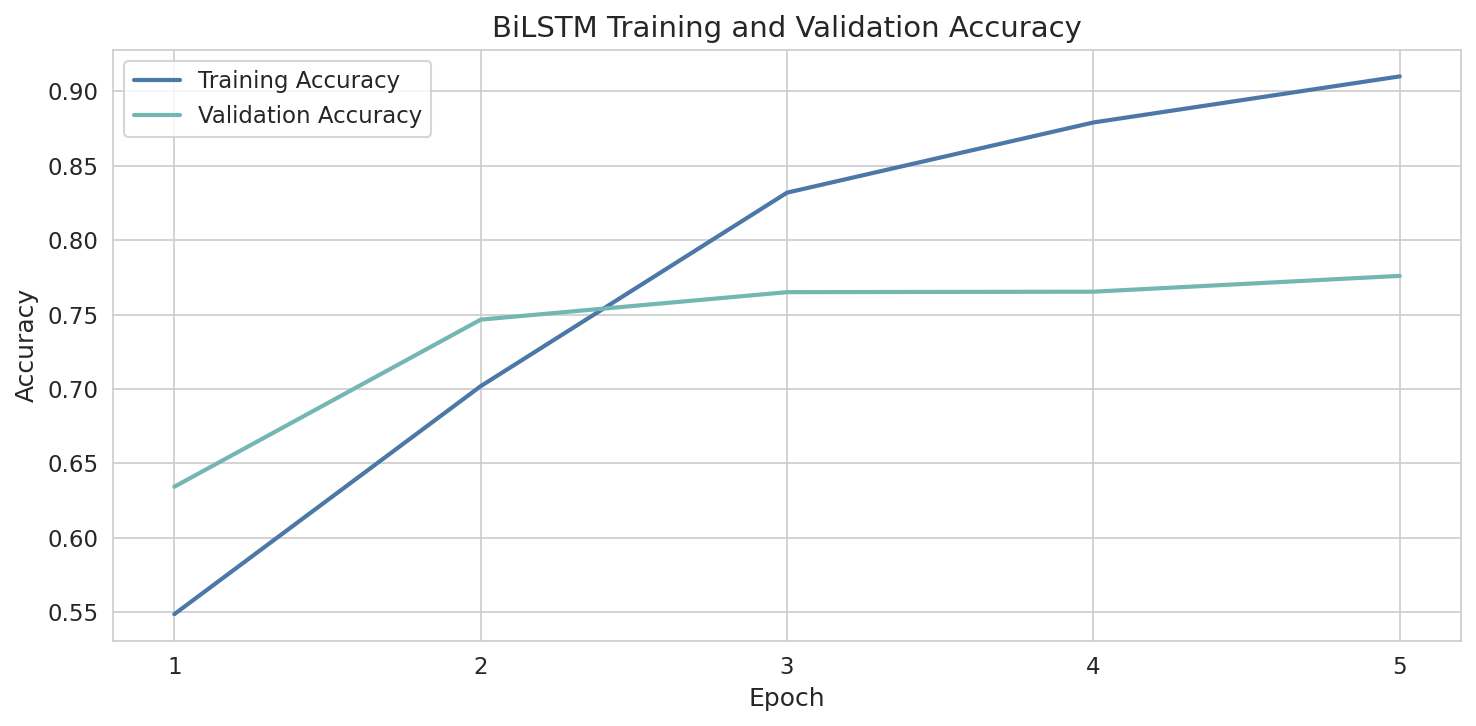

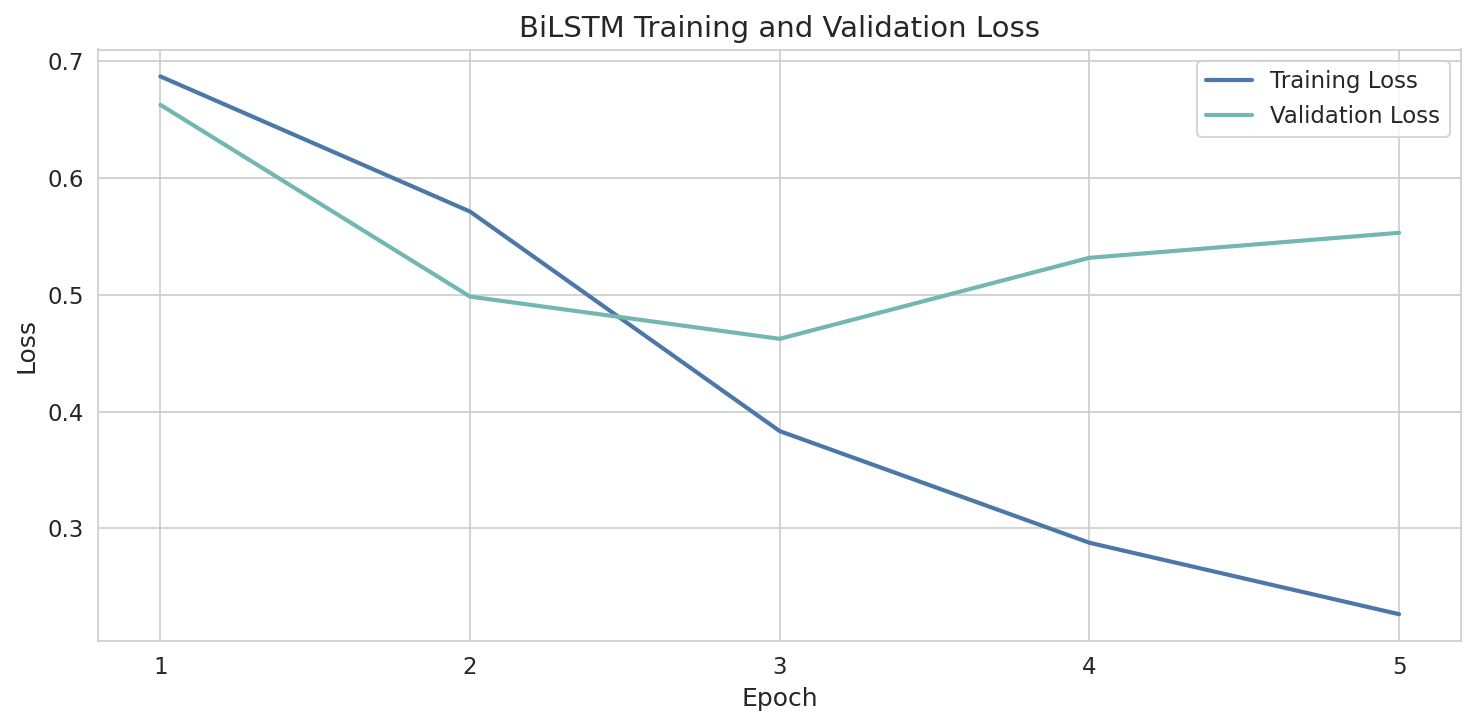

In [ ]:
# ===== Cell 30: BiLSTM Training Curves =====

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df.index + 1, history_df["accuracy"], label="Training Accuracy", linewidth=2, color="#4C78A8")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Validation Accuracy", linewidth=2, color="#72B7B2")

plt.title("BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(history_df.index + 1)
plt.legend()
plt.tight_layout()
plt.savefig("bilstm_accuracy_curve.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df.index + 1, history_df["loss"], label="Training Loss", linewidth=2, color="#4C78A8")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Validation Loss", linewidth=2, color="#72B7B2")

plt.title("BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(history_df.index + 1)
plt.legend()
plt.tight_layout()
plt.savefig("bilstm_loss_curve.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 31: BiLSTM Test Metrics =====

y_pred_prob_bilstm = bilstm_model.predict(X_test_pad).flatten()
y_pred_bilstm = (y_pred_prob_bilstm >= 0.5).astype(int)

print("BiLSTM Results")
print("Accuracy :", accuracy_score(y_test, y_pred_bilstm))
print("Precision:", precision_score(y_test, y_pred_bilstm))
print("Recall   :", recall_score(y_test, y_pred_bilstm))
print("F1 Score :", f1_score(y_test, y_pred_bilstm))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
BiLSTM Results
Accuracy : 0.772
Precision: 0.7486288848263254
Recall   : 0.819
F1 Score : 0.7822349570200573


              precision    recall  f1-score   support

           0       0.80      0.72      0.76      2000
           1       0.75      0.82      0.78      2000

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000



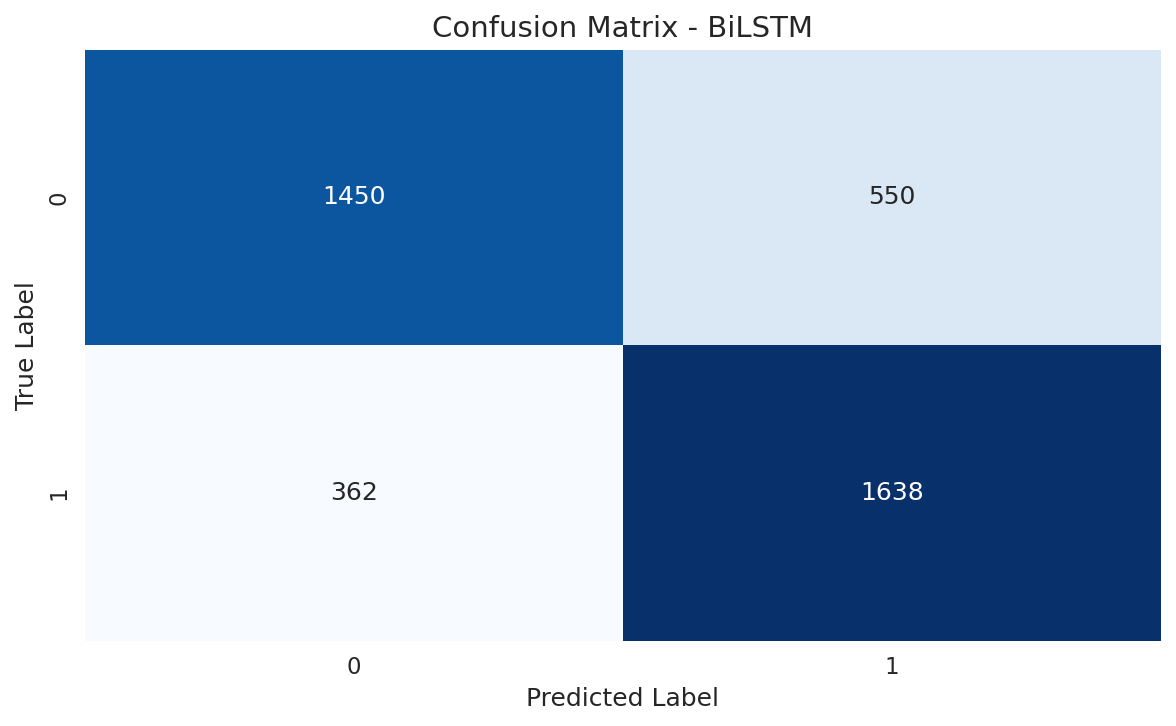

In [ ]:
# ===== Cell 32: BiLSTM Report + Confusion Matrix =====

print(classification_report(y_test, y_pred_bilstm))

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)

plt.figure()
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix_bilstm.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 33: Final Results Table =====

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "BiLSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_bilstm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_bilstm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_bilstm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_bilstm)
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76075,0.745643,0.7915,0.767887
1,SVM,0.76000,0.755403,0.7690,0.762141
2,Random Forest,0.73700,0.707713,0.8075,0.754320
3,BiLSTM,0.77200,0.748629,0.8190,0.782235


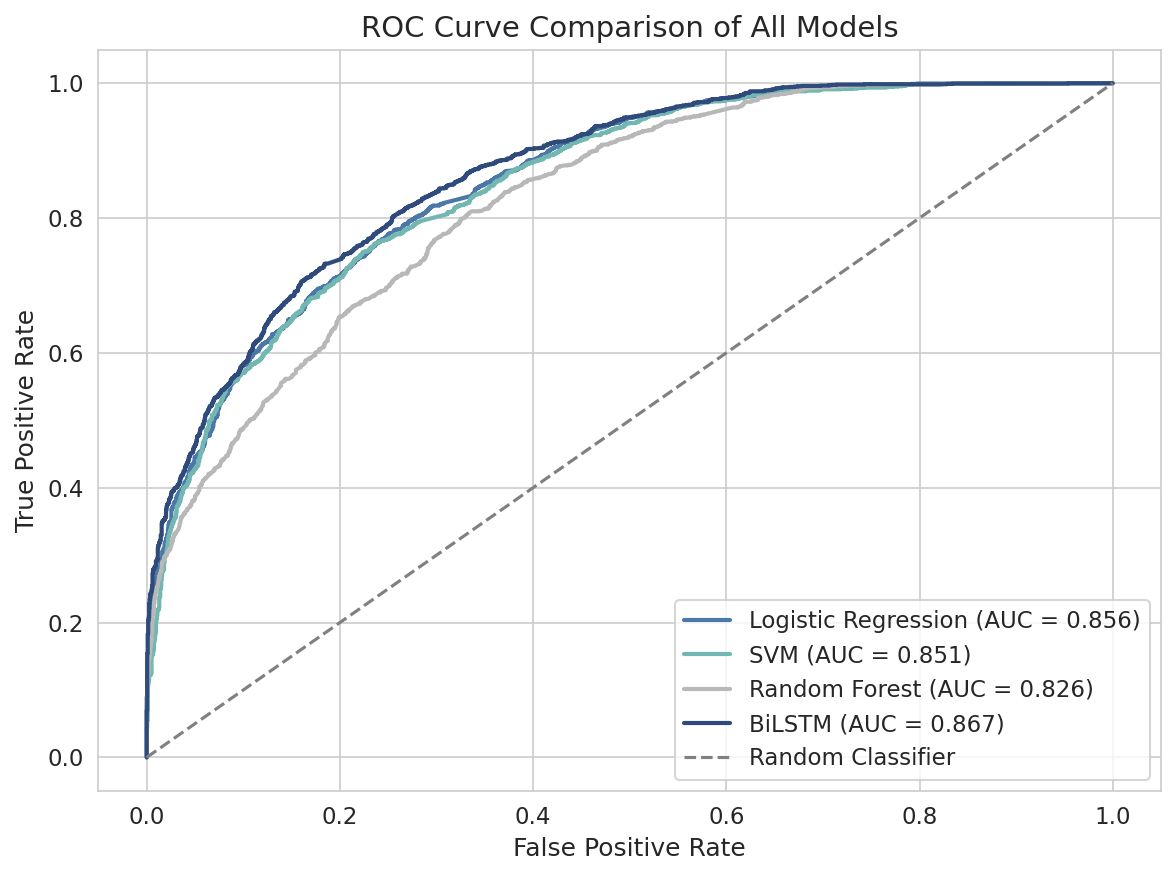

AUC Scores
Logistic Regression: 0.8564
SVM                : 0.8515
Random Forest      : 0.8263
BiLSTM             : 0.8668


In [ ]:
# ===== Cell 34: Combined ROC-AUC Curve =====

y_score_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]
y_score_svm = svm_model.decision_function(X_test_tfidf)
y_score_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]
y_score_bilstm = y_pred_prob_bilstm

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_test, y_score_bilstm)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_rf = auc(fpr_rf, tpr_rf)
auc_bilstm = auc(fpr_bilstm, tpr_bilstm)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2, color="#4C78A8")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})", linewidth=2, color="#72B7B2")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2, color="#B8B8B8")
plt.plot(fpr_bilstm, tpr_bilstm, label=f"BiLSTM (AUC = {auc_bilstm:.3f})", linewidth=2, color="#2F4B7C")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="gray", label="Random Classifier")

plt.title("ROC Curve Comparison of All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("combined_roc_auc_all_models.png", bbox_inches="tight")
plt.show()

print("AUC Scores")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"SVM                : {auc_svm:.4f}")
print(f"Random Forest      : {auc_rf:.4f}")
print(f"BiLSTM             : {auc_bilstm:.4f}")

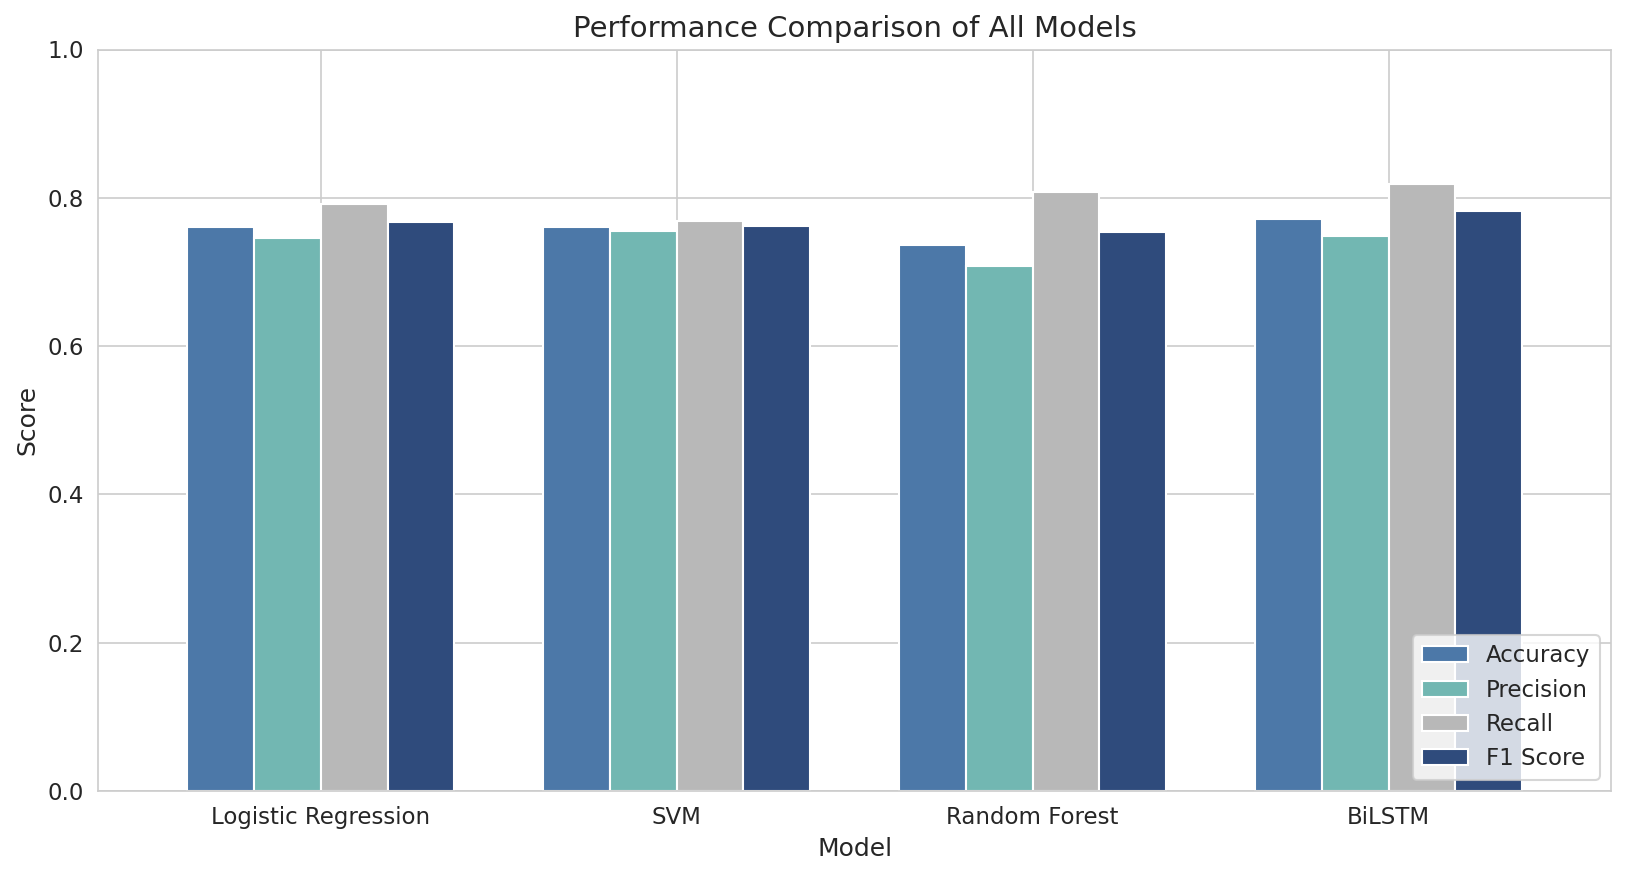

In [ ]:
# ===== Cell 35: Final Comparison Bar Graph for All Models =====

final_plot = final_results.set_index("Model")

academic_colors = ["#4C78A8", "#72B7B2", "#B8B8B8", "#2F4B7C"]

ax = final_plot.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75,
    color=academic_colors
)

plt.title("Performance Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("all_models_comparison.png", bbox_inches="tight")
plt.show()

In [ ]:
# ===== Cell 36: Best Model =====

best_model_row = final_results.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Model Based on F1 Score:")
print(best_model_row)

Best Model Based on F1 Score:
Model          BiLSTM
Accuracy        0.772
Precision    0.748629
Recall          0.819
F1 Score     0.782235
Name: 3, dtype: object


In [ ]:
# ===== Cell 37: Save Final Results Table =====

final_results.to_csv("final_model_results.csv", index=False)
print("Saved as: final_model_results.csv")

Saved as: final_model_results.csv


In [ ]:
# ===== Cell 38: Sample Predictions Table =====

sample_results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": y_pred_bilstm,
    "prediction_score": y_pred_prob_bilstm
})

sample_results.head(10)

,text,true_label,predicted_label,prediction_score
0,awesome,1,1,0.822552
1,southington inn motor lodge southington ct,0,0,0.141236
2,disclaimer this is hard to watch dawg all son ...,0,0,0.038249
3,roar bbmas,1,1,0.938665
4,now nowzayn vote for zayn until you come back ...,0,0,0.027431
5,damn dis shit is like common courtesy u bitche...,0,0,0.485947
6,twitter what have you done,1,1,0.630989
7,i know the voice but it also sounded like his ...,0,0,0.127136
8,is your child well disciplined,1,1,0.735941
9,will there ever come a time when i am not hope...,1,1,0.565229


In [ ]:
# ===== Cell 39: Error Analysis Table =====

sample_results["result"] = np.where(
    sample_results["true_label"] == sample_results["predicted_label"],
    "Correct",
    "Wrong"
)

wrong_predictions = sample_results[sample_results["result"] == "Wrong"].copy()
wrong_predictions.head(10)

,text,true_label,predicted_label,prediction_score,result
10,easy moves that rev your metabolism via,1,0,0.419592,Wrong
11,turn back you still have your entire life ahea...,1,0,0.483824,Wrong
22,tell me this isn t true,0,1,0.776263,Wrong
28,nothing,0,1,0.683094,Wrong
29,nooo its not c you will find the right people ...,1,0,0.144907,Wrong
35,catching my cat skulking around weird places i...,0,1,0.890449,Wrong
38,me vs trying not to quote all of britts live t...,0,1,0.674600,Wrong
42,oh well you got me under your spell,1,0,0.420396,Wrong
48,ultimate apparels,0,1,0.519875,Wrong
50,i feel like an invisible hand is trying to rem...,1,0,0.305570,Wrong


In [ ]:
# ===== Cell 40: High and Low Confidence Predictions =====

# highest confidence correct predictions
high_conf_correct = sample_results[
    sample_results["true_label"] == sample_results["predicted_label"]
].copy()

high_conf_correct["confidence"] = np.where(
    high_conf_correct["predicted_label"] == 1,
    high_conf_correct["prediction_score"],
    1 - high_conf_correct["prediction_score"]
)

high_conf_correct = high_conf_correct.sort_values(by="confidence", ascending=False)

print("Top 10 High-Confidence Correct Predictions")
high_conf_correct[["text", "true_label", "predicted_label", "prediction_score", "confidence"]].head(10)

Top 10 High-Confidence Correct Predictions


,text,true_label,predicted_label,prediction_score,confidence
863,depression treatments can depression treatment...,1,1,0.999025,0.999025
2487,overcome depression how to overcome depression...,1,1,0.998973,0.998973
2426,health on pinterest depression overcoming depr...,1,1,0.998754,0.998754
212,overcome depression new research supports the ...,1,1,0.998668,0.998668
2331,exercise may help alleviate depression depress...,1,1,0.998596,0.998596
648,how to overcome depression with diet depressio...,1,1,0.998323,0.998323
3008,overcome depression study identifies which bip...,1,1,0.998251,0.998251
2142,depression treatments tropical depression in t...,1,1,0.998226,0.998226
3501,biomarkers to finetune depression treatment me...,1,1,0.998219,0.998219
2645,meditation for depression and stress relief ov...,1,1,0.998214,0.998214


In [ ]:
# ===== Cell 41: Single Sentence Prediction =====

def predict_depression(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    score = bilstm_model.predict(pad, verbose=0)[0][0]
    label = "Depressed" if score >= 0.5 else "Not Depressed"

    result = pd.DataFrame({
        "input_text": [text],
        "cleaned_text": [cleaned],
        "prediction_score": [round(float(score), 6)],
        "predicted_class": [label]
    })

    return result

In [ ]:
# ===== Cell 42: Example Prediction =====

predict_depression("yess i won")

,input_text,cleaned_text,prediction_score,predicted_class
0,yess i won,yess i won,0.651149,Depressed


**Final output**

In [ ]:
# ===== Final Demo Cell: Prediction Table for Paper =====

custom_sentences = [
    "I hate myself and I feel hopeless every day.",
    "Nothing feels worth it anymore.",
    "I feel tired, broken, and lost all the time.",
    "I enjoyed a peaceful day with my family.",
    "I am excited"
]

def predict_multiple_sentences(sentences):
    cleaned_sentences = [clean_text(text) for text in sentences]
    sequences = tokenizer.texts_to_sequences(cleaned_sentences)
    padded = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

    prediction_scores = bilstm_model.predict(padded, verbose=0).flatten()
    predicted_classes = ["Depressed" if score >= 0.5 else "Not Depressed" for score in prediction_scores]

    results_table = pd.DataFrame({
        "Input Sentence": sentences,
        "Prediction Score": [round(float(score), 6) for score in prediction_scores],
        "Predicted Class": predicted_classes
    })

    return results_table

predict_multiple_sentences(custom_sentences)

,Input Sentence,Prediction Score,Predicted Class
0,I hate myself and I feel hopeless every day.,0.928096,Depressed
1,Nothing feels worth it anymore.,0.928985,Depressed
2,"I feel tired, broken, and lost all the time.",0.919250,Depressed
3,I enjoyed a peaceful day with my family.,0.744846,Depressed
4,I am excited,0.875012,Depressed


In [ ]:
# ===== Final Demo Table for Thesis Paper =====

correct_predictions = sample_results[
    sample_results["true_label"] == sample_results["predicted_label"]
].copy()

depressed_examples = correct_predictions[
    correct_predictions["predicted_label"] == 1
][["text", "prediction_score", "predicted_label"]].head(2)

not_depressed_examples = correct_predictions[
    correct_predictions["predicted_label"] == 0
][["text", "prediction_score", "predicted_label"]].head(2)

demo_table = pd.concat([depressed_examples, not_depressed_examples], axis=0).reset_index(drop=True)

demo_table["predicted_label"] = demo_table["predicted_label"].map({
    1: "Depressed",
    0: "Not Depressed"
})

demo_table["prediction_score"] = demo_table["prediction_score"].round(6)

demo_table.columns = ["Input Sentence", "Prediction Score", "Predicted Class"]

demo_table

,Input Sentence,Prediction Score,Predicted Class
0,awesome,0.822552,Depressed
1,roar bbmas,0.938665,Depressed
2,southington inn motor lodge southington ct,0.141236,Not Depressed
3,disclaimer this is hard to watch dawg all son ...,0.038249,Not Depressed
